In [1]:
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pq.ParquetDataset(
    '../dataset/prom_slurm_joined/prom_slurm_joined.parquet',
    filters=[('gpu_node', '=', 1)]
)

fragments = []
for fragment in dataset.fragments:
    batch = fragment.to_table(
        filter=pa.compute.field('gpu_node') == 1
    ).to_pandas()
    sample = batch.groupby('state', group_keys=False).apply(
        lambda x: x.sample(frac=0.02, random_state=42)
    )
    fragments.append(sample)

df = pd.concat(fragments).reset_index(drop=True)
print(df.shape)
print(df['state'].value_counts())

C:\Users\fcall\AppData\Local\Temp\ipykernel_9288\2735977752.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = batch.groupby('state', group_keys=False).apply(
C:\Users\fcall\AppData\Local\Temp\ipykernel_9288\2735977752.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = batch.groupby('state', group_keys=False).apply(
C:\Users\fcall\AppData\Local\Temp\ipykernel_9288\2735977752.py:11: Dep

(269188, 100)
state
COMPLETED        135389
TIMEOUT           72869
CANCELLED         46290
FAILED            12622
OUT_OF_MEMORY      1462
NODE_FAIL           556
Name: count, dtype: int64


In [21]:
fragment = list(dataset.fragments)[0]

df_fragment = fragment.to_table().to_pandas()
df_fragment.head(20)

,prom_id,timestamp,node,node_time_seconds,node_load15,node_power_usage,up,node_netstat_Tcp_OutSegs,node_netstat_Tcp_InErrs,node_context_switches_total,...,gpu_node,slurm_id,submit_date,start_date,end_date,nodetypes,numnodes,numcores,state,slurm_nodes
0,7247237,2022-07-04 09:36:00,r10n1,1.656930e+09,0.01,36.0,1.0,4.441490e+10,3.0,5.004180e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
1,7247238,2022-07-04 09:36:30,r10n1,1.656930e+09,0.04,92.0,1.0,4.441500e+10,3.0,5.004180e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
2,7247239,2022-07-04 09:37:00,r10n1,1.656930e+09,0.07,92.0,1.0,4.441500e+10,3.0,5.004180e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
3,7247240,2022-07-04 09:37:30,r10n1,1.656930e+09,0.10,92.0,1.0,4.441500e+10,3.0,5.004180e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
4,7247241,2022-07-04 09:38:00,r10n1,1.656930e+09,0.32,92.0,1.0,4.441510e+10,3.0,5.004180e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
5,7247242,2022-07-04 09:38:30,r10n1,1.656930e+09,1.21,92.0,1.0,4.441510e+10,3.0,5.004210e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
6,7247243,2022-07-04 09:39:00,r10n1,1.656930e+09,2.16,92.0,1.0,4.441510e+10,3.0,5.004230e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
7,7247244,2022-07-04 09:39:30,r10n1,1.656930e+09,2.66,92.0,1.0,4.441510e+10,3.0,5.004230e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
8,7247245,2022-07-04 09:40:00,r10n1,1.656930e+09,3.22,92.0,1.0,4.441510e+10,3.0,5.004240e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]
9,7247246,2022-07-04 09:40:30,r10n1,1.656930e+09,3.99,128.0,1.0,4.441510e+10,3.0,5.004270e+11,...,0,1603441,2022-07-04 09:35:36,2022-07-04 09:35:36,2022-07-09 03:44:42,normal,1,16,TIMEOUT,[r10n1]


In [14]:
null_rates = df.isnull().mean().sort_values(ascending=False)
print(null_rates[null_rates > 0])


Series([], dtype: float64)


In [13]:
df['label'] = (df['state'] != 'COMPLETED').astype(int)
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).round(3))

label
0    135389
1    133799
Name: count, dtype: int64
label
0    0.503
1    0.497
Name: proportion, dtype: float64


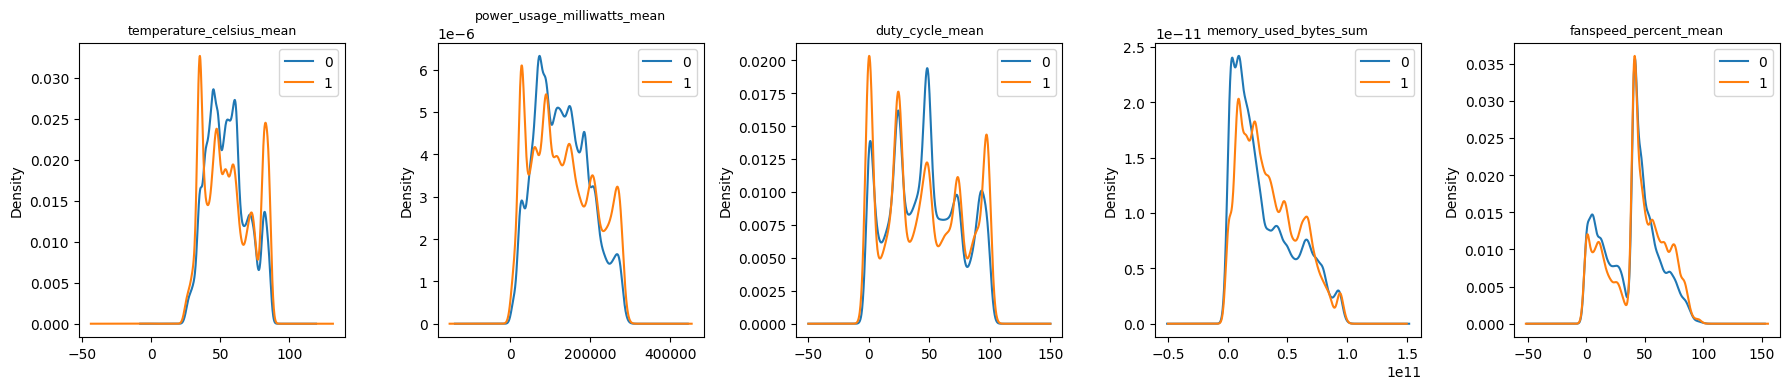

In [ ]:
gpu_cols = [
    'nvidia_gpu_temperature_celsius_mean',
    'nvidia_gpu_power_usage_milliwatts_mean',
    'nvidia_gpu_duty_cycle_mean',
    'nvidia_gpu_memory_used_bytes_sum',
    'nvidia_gpu_fanspeed_percent_mean'
]

fig, axes = plt.subplots(1, len(gpu_cols), figsize=(18, 4))
for ax, col in zip(axes, gpu_cols):
    df.groupby('label')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col.replace('nvidia_gpu_', ''), fontsize=9)
    ax.set_xlabel('')
plt.tight_layout()          
plt.show()

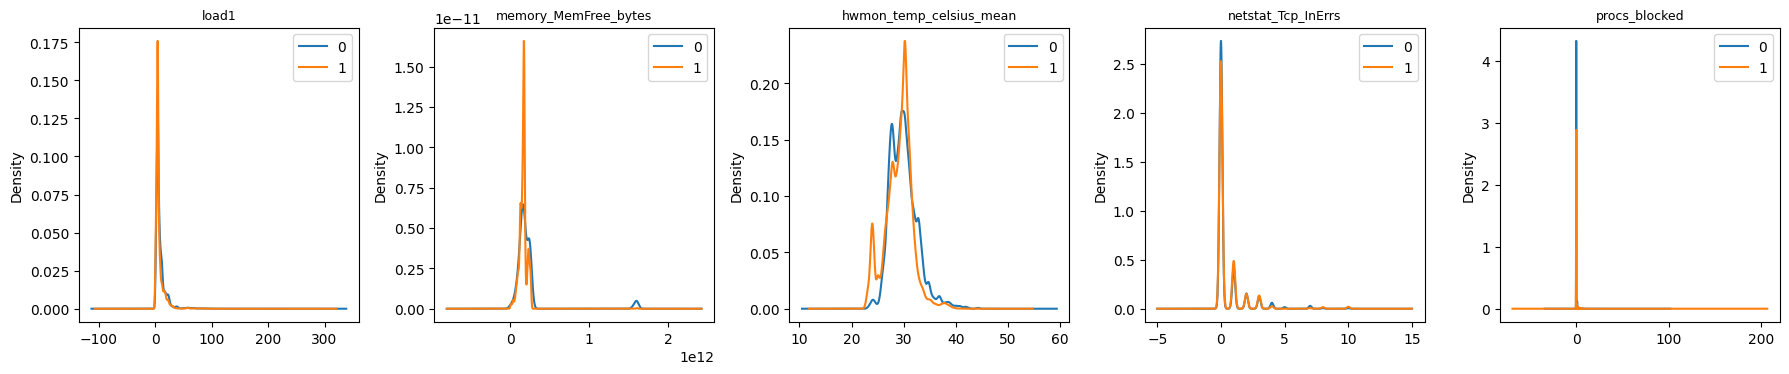

In [16]:
node_cols = [
    'node_load1',
    'node_memory_MemFree_bytes',
    'node_hwmon_temp_celsius_mean',
    'node_netstat_Tcp_InErrs',
    'node_procs_blocked'
]

fig, axes = plt.subplots(1, len(node_cols), figsize=(18, 4))
for ax, col in zip(axes, node_cols):
    df.groupby('label')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col.replace('node_', ''), fontsize=9)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [17]:
feature_cols = gpu_cols + node_cols
corr = df[feature_cols + ['label']].corr()['label'].drop('label').sort_values(key=abs, ascending=False)
print(corr)

node_hwmon_temp_celsius_mean             -0.165342
node_memory_MemFree_bytes                -0.149603
node_load1                               -0.101792
nvidia_gpu_fanspeed_percent_mean          0.099177
nvidia_gpu_memory_used_bytes_sum          0.082923
nvidia_gpu_temperature_celsius_mean       0.033382
node_procs_blocked                        0.025390
nvidia_gpu_power_usage_milliwatts_mean    0.012546
node_netstat_Tcp_InErrs                   0.004281
nvidia_gpu_duty_cycle_mean               -0.001568
Name: label, dtype: float64
